## Name : Pranav Soitkar
## Class : C2
## Batch : B2
## Roll no. : 24

**LAB 7 ML**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix,ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv("Raisin_Dataset.xlsx - Raisin_Grains_Dataset.csv")

In [7]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [8]:
df.tail()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni
899,85609,512.081774,215.271976,0.907345,89197,0.632020,1272.862,Besni


In [9]:
df.isnull().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
Extent,0
Perimeter,0
Class,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Class'].unique()

array(['Kecimen', 'Besni'], dtype=object)

In [12]:
df['Class'].value_counts()

,count
Class,
Kecimen,450
Besni,450


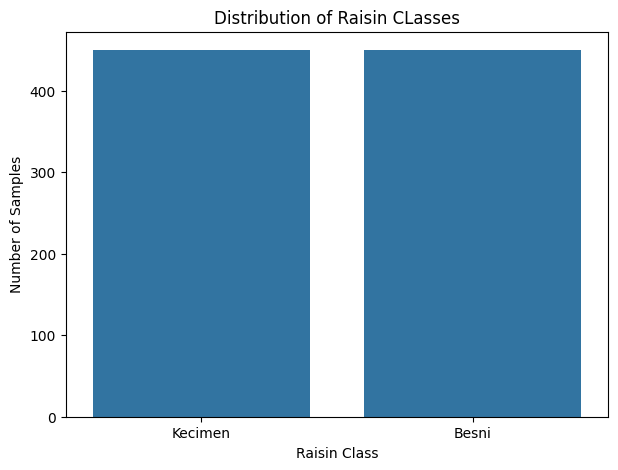

In [13]:
## Bar Plot
plt.figure(figsize=(7,5))
sns.countplot(x='Class',data=df)

plt.title("Distribution of Raisin CLasses")
plt.xlabel("Raisin Class")
plt.ylabel("Number of Samples")
plt.show()

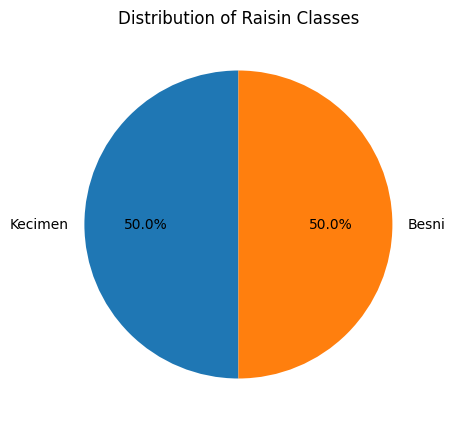

In [14]:
##Pie Chart
class_counts = df['Class'].value_counts()
plt.figure(figsize=(7,5))
plt.pie(class_counts, labels=class_counts.index,autopct='%1.1f%%',startangle=90)
plt.title("Distribution of Raisin Classes")
plt.show()

In [15]:
numerical_features = df.select_dtypes(include = np.number).columns

print("Numerical Features:")
print(numerical_features.tolist())

Numerical Features:
['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Extent', 'Perimeter']


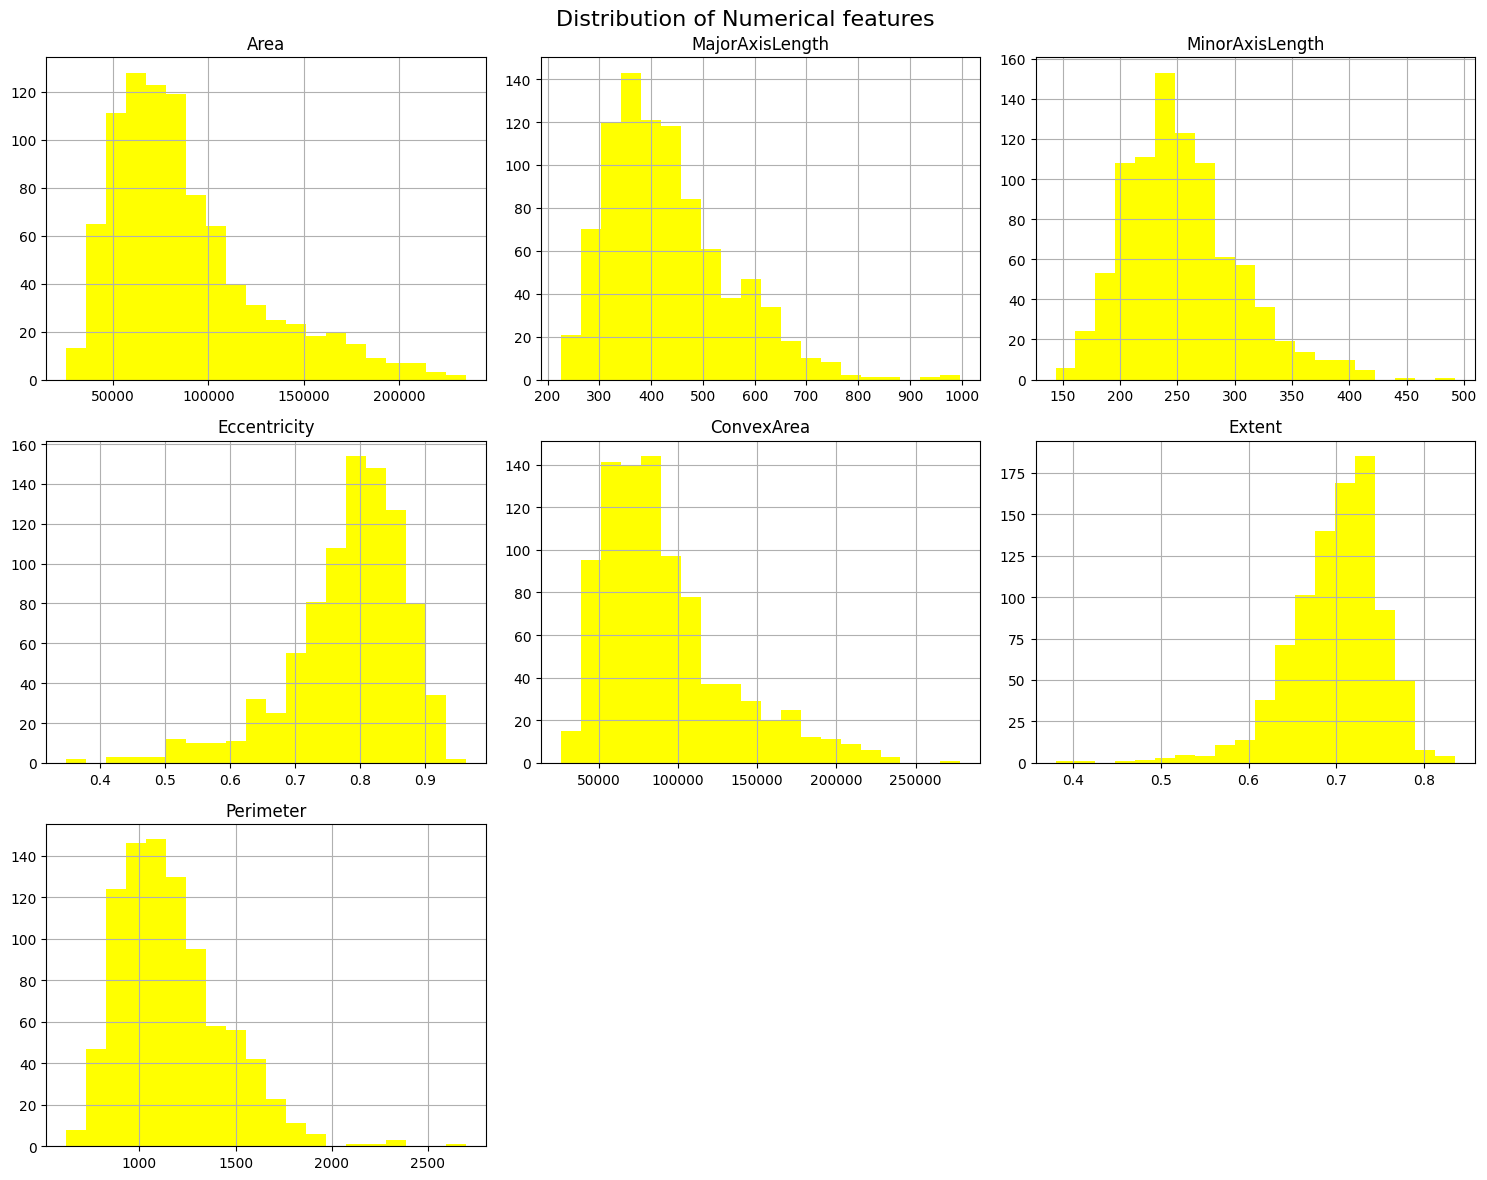

In [16]:
## Histograms
df[numerical_features].hist(figsize=(15,12),bins=20,color='yellow')
plt.suptitle('Distribution of Numerical features',fontsize=16)
plt.tight_layout()
plt.show()

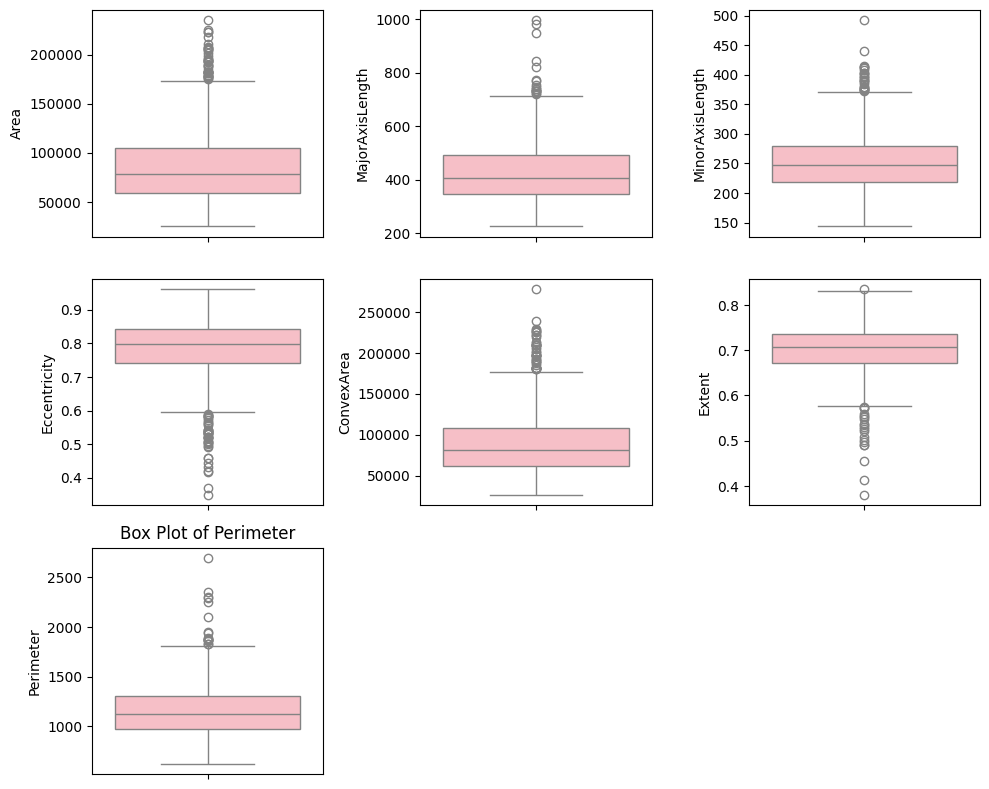

In [17]:
plt.figure(figsize=(10,8))

for i, column in enumerate(numerical_features, 1):
  plt.subplot(3,3,i)
  sns.boxplot(y=df[column],color='lightpink')
plt.title(f"Box Plot of {column}")
plt.tight_layout()
plt.show()

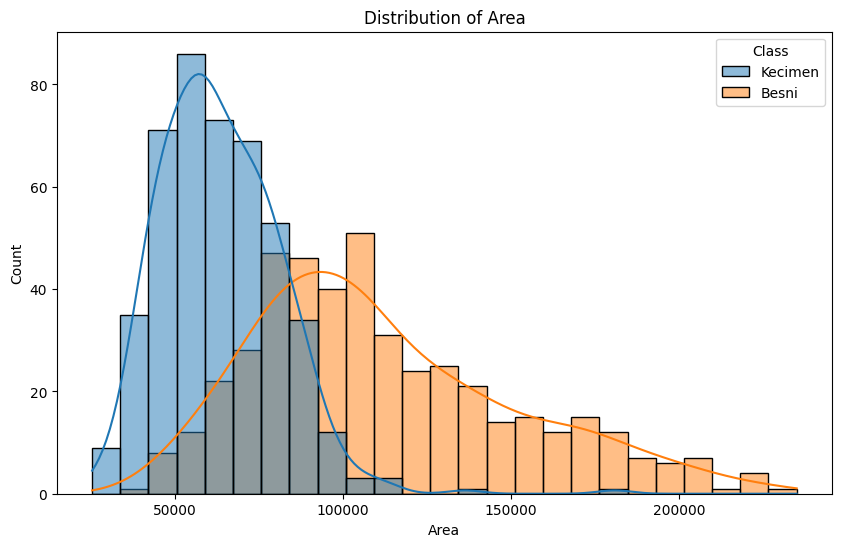

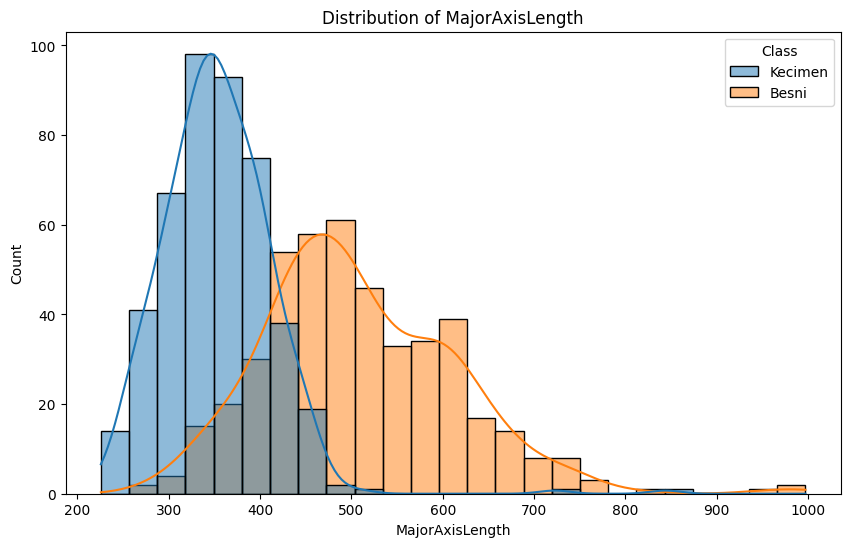

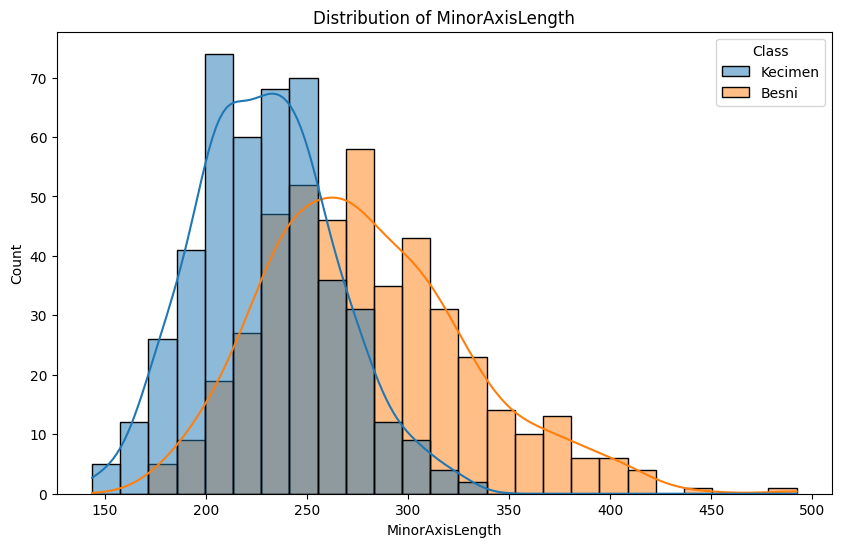

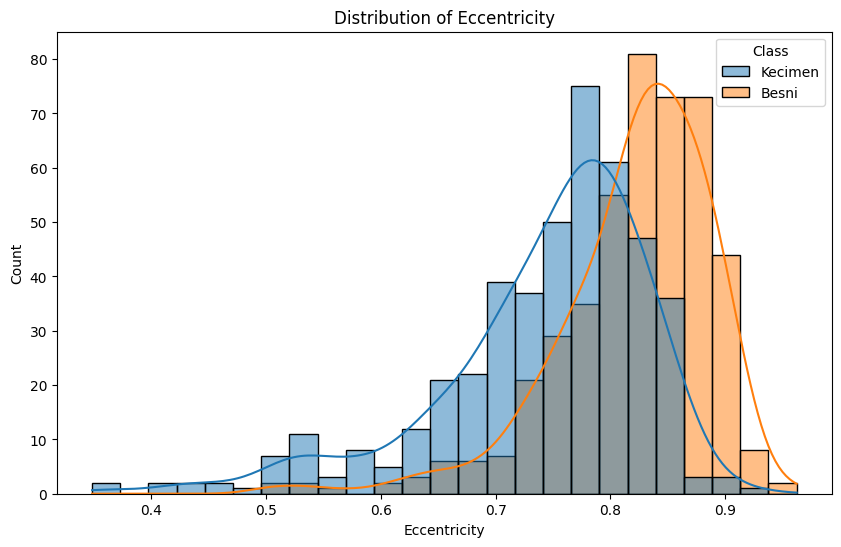

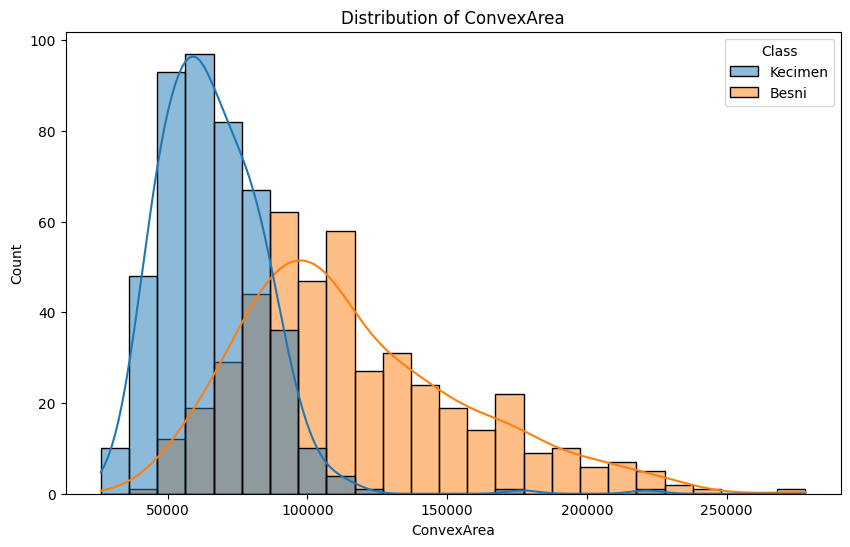

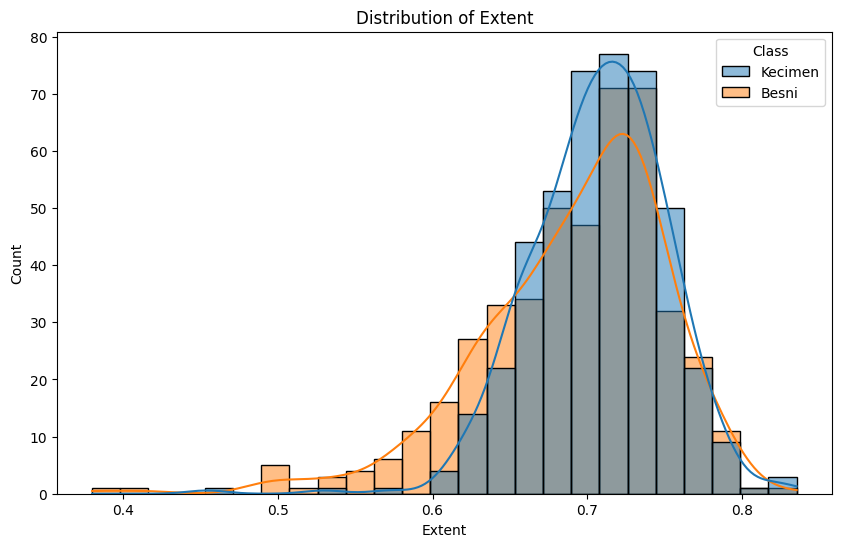

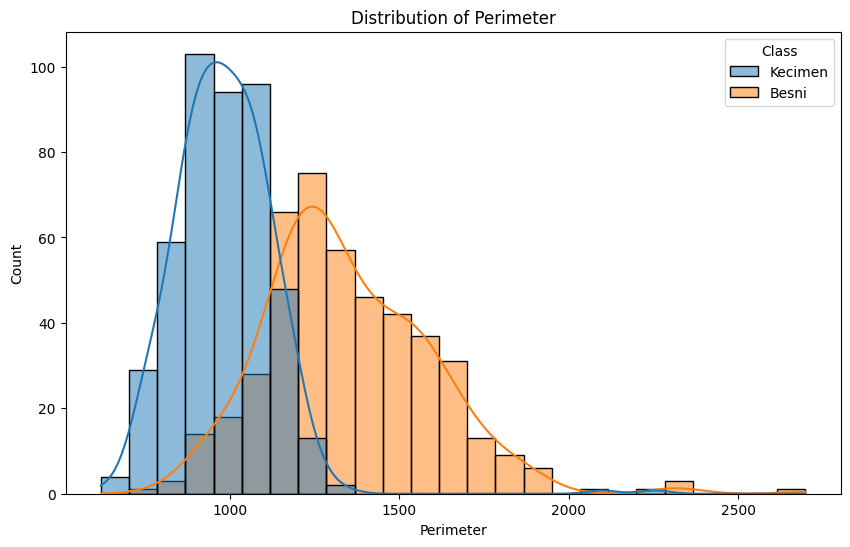

In [18]:
## Histogram with kde function
for column in numerical_features:
  plt.figure(figsize=(10,6))
  sns.histplot(data=df , x =column, hue='Class', kde = True,bins = 25)
  plt.title(f"Distribution of {column}")
  plt.show()

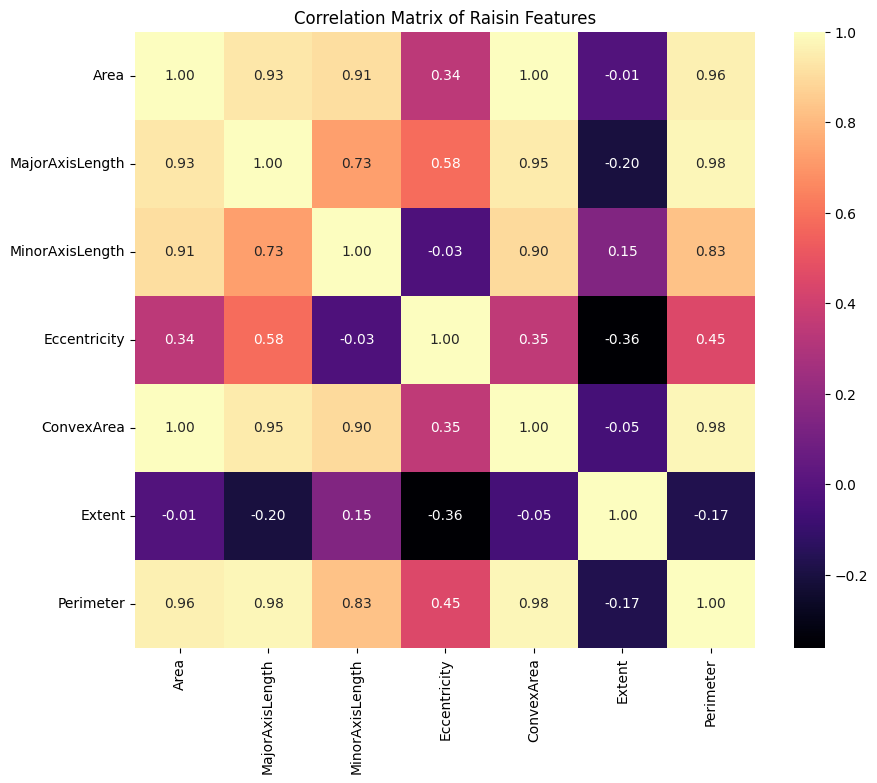

In [19]:
##Correlation matrix
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='magma',fmt=".2f")
plt.title("Correlation Matrix of Raisin Features")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

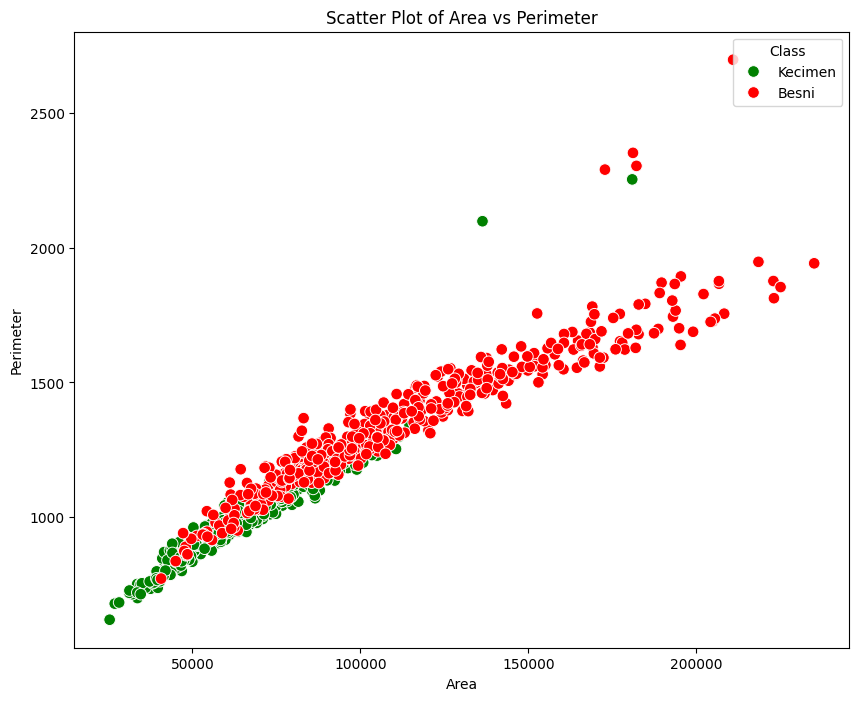

In [20]:
## SCatter plot
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x="Area", y="Perimeter",palette={'Kecimen': 'Green', 'Besni': 'Red'}, hue='Class',s = 70)
plt.title("Scatter Plot of Area vs Perimeter")
plt.show

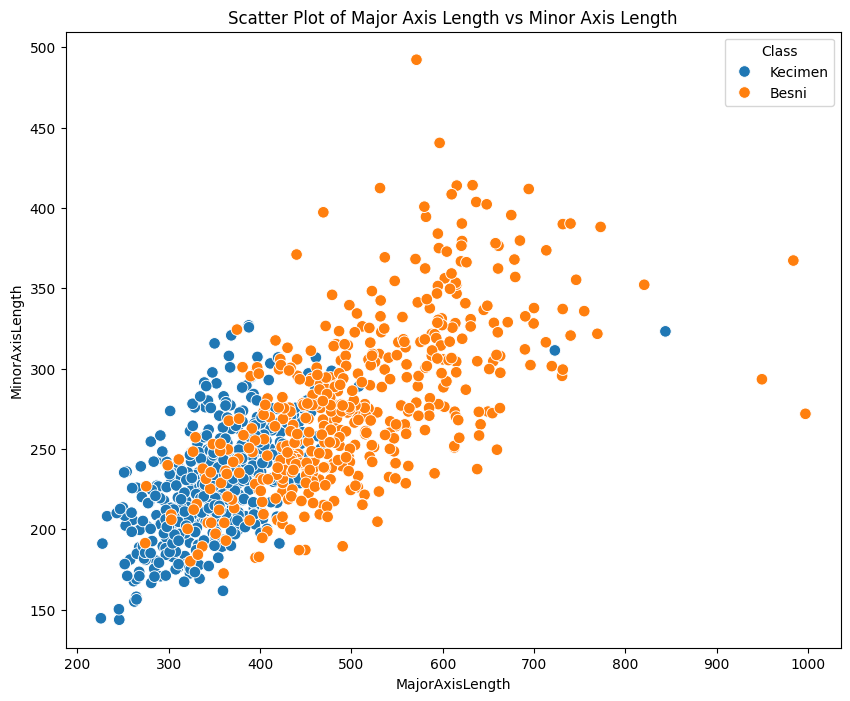

In [21]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x="MajorAxisLength", y="MinorAxisLength",hue='Class',s = 70)
plt.title("Scatter Plot of Major Axis Length vs Minor Axis Length")
plt.show()

In [22]:
label_encoder  = LabelEncoder()
df['Class_encoded'] = label_encoder.fit_transform(df['Class'])
print(df[['Class', 'Class_encoded']].head(10))

     Class  Class_encoded
0  Kecimen              1
1  Kecimen              1
2  Kecimen              1
3  Kecimen              1
4  Kecimen              1
5  Kecimen              1
6  Kecimen              1
7  Kecimen              1
8  Kecimen              1
9  Kecimen              1


In [23]:
print("Class mapping:")

for index,class_name in enumerate(label_encoder.classes_):
  print(index,"=", class_name)

Class mapping:
0 = Besni
1 = Kecimen


In [24]:
X = df[numerical_features]
y = df['Class_encoded']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (900, 7)
Shape of y: (900,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 720
Testing samples: 180


In [26]:
GaussianNB()

GaussianNB()

In [27]:
gnb = GaussianNB()

gnb.fit(X_train,y_train)

GaussianNB()

In [28]:
y_pred = gnb.predict(X_test)
print("predicted Labels:")
print(y_pred)

predicted Labels:
[1 0 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 1
 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 0 1 1 0
 1 1 0 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1
 1 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1]


In [29]:
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(comparison.head(5))

   Actual  Predicted
0       0          1
1       0          0
2       0          0
3       1          1
4       0          0


In [30]:
comparison['Actual_Class'] = label_encoder.inverse_transform(comparison['Actual'])
comparison['Predicted_Class'] = label_encoder.inverse_transform(comparison['Predicted'])
print(comparison.head(5))

   Actual  Predicted Actual_Class Predicted_Class
0       0          1        Besni         Kecimen
1       0          0        Besni           Besni
2       0          0        Besni           Besni
3       1          1      Kecimen         Kecimen
4       0          0        Besni           Besni


In [31]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8166666666666667
Accuracy (%): 81.66666666666667


In [32]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
print("Precision (%):", precision * 100)

Precision: 0.7522123893805309
Precision (%): 75.22123893805309


In [33]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9444444444444444


In [34]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8374384236453202


In [35]:
print("==== MODEL PERFORMANCE ====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

==== MODEL PERFORMANCE ====
Accuracy: 0.8167
Precision: 0.7522
Recall: 0.9444
F1 Score: 0.8374


In [36]:
print("Classification Report: \n")
print(classification_report(y_test, y_pred))

Classification Report: 

              precision    recall  f1-score   support

           0       0.93      0.69      0.79        90
           1       0.75      0.94      0.84        90

    accuracy                           0.82       180
   macro avg       0.84      0.82      0.81       180
weighted avg       0.84      0.82      0.81       180



In [37]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[62 28]
 [ 5 85]]


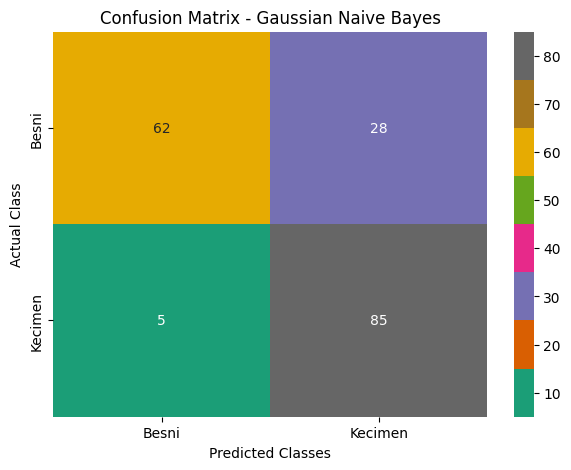

In [38]:
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Dark2', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Classes')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.show()

In [39]:
from sklearn.metrics import accuracy_score

y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8263888888888888
Testing Accuracy: 0.8166666666666667


In [40]:
## Main_Hyperparameters
GaussianNB(var_smoothing=1e-9)

GaussianNB()

In [41]:
print(gnb.get_params())

{'priors': None, 'var_smoothing': 1e-09}


In [42]:
smoothing_values = [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2 ]
results = []

for value in smoothing_values:
  model = GaussianNB(var_smoothing = value)
  model.fit(X_train, y_train)
  prediction = model.predict(X_test)
  acc = accuracy_score(y_test, prediction)
  prec = precision_score(y_test, prediction)
  rec = recall_score(y_test, prediction)
  f1_value = f1_score(y_test, prediction)
  results.append([value, acc,prec,rec,f1_value])

In [43]:
results_df = pd.DataFrame(results, columns=['var_smoothing', 'Accuracy','Precision','Recall','F1-Score'])
print(results_df)

    var_smoothing  Accuracy  Precision    Recall  F1-Score
0    1.000000e-12  0.833333   0.767857  0.955556  0.851485
1    1.000000e-10  0.816667   0.752212  0.944444  0.837438
2    1.000000e-09  0.816667   0.752212  0.944444  0.837438
3    1.000000e-08  0.816667   0.752212  0.944444  0.837438
4    1.000000e-07  0.811111   0.745614  0.944444  0.833333
5    1.000000e-07  0.811111   0.745614  0.944444  0.833333
6    1.000000e-06  0.811111   0.745614  0.944444  0.833333
7    1.000000e-05  0.811111   0.741379  0.955556  0.834951
8    1.000000e-04  0.788889   0.720339  0.944444  0.817308
9    1.000000e-03  0.788889   0.720339  0.944444  0.817308
10   1.000000e-02  0.783333   0.714286  0.944444  0.813397


In [44]:
area = float(input("Enter Area : "))
major_axis = float(input("Enter Major Axis Length : "))
minor_axis = float(input("Enter Minor Axis Length : "))
eccentricity = float(input("Enter Eccentricity : "))
convex_area = float(input("Enter Convex Area : "))
extent = float(input("Enter Extent : "))
perimeter = float(input("Enter Perimeter : "))

new_sample = pd.DataFrame({
    'Area': [area],
    'MajorAxisLength': [major_axis],
    'MinorAxisLength': [minor_axis],
    'Eccentricity': [eccentricity],
    'ConvexArea': [convex_area],
    'Extent': [extent],
    'Perimeter': [perimeter]
})

prediction = gnb.predict(new_sample)

predicted_class = label_encoder.inverse_transform(prediction)

print("\nPredicted Raisin Class:", predicted_class[0])

Enter Area : 1.56
Enter Major Axis Length : 2.1
Enter Minor Axis Length : 1.4
Enter Eccentricity : 1.1
Enter Convex Area : 2.6
Enter Extent : 3.1
Enter Perimeter : 3.5

Predicted Raisin Class: Besni
